---
# EMITTANCE EXCHANGE INSERTION
---
https://cds.cern.ch/record/261067/files/p219.pdf


Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


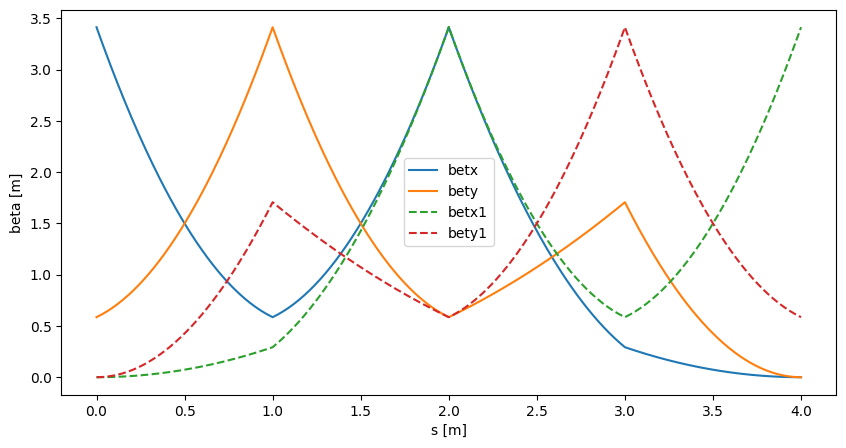

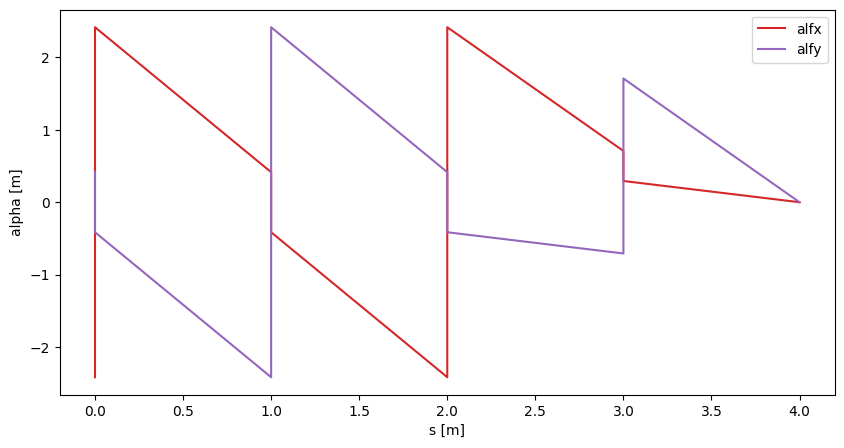

In [6]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

import xtrack as xt
import xobjects as xo


# CELL parameters
#-----------------------
L       = 1                 #-- drift length
k       = np.sqrt(2)/L      #-- focusing strength
divs    = 100               #-- drift divisions (for visualization)
#-----------------------


# Expected twiss
#-----------------------
mu = 0.25
betx = L*k*(2/k + L) / np.sin(2*np.pi*mu)
bety = L*k*(2/k - L) / np.sin(2*np.pi*mu)
alfx = -L*k*(1+ L*k/2) / np.sin(2*np.pi*mu)
alfy =  L*k*(1- L*k/2) / np.sin(2*np.pi*mu)
twiss_init = xt.TwissInit(betx=betx, bety=bety, alfx=alfx, alfy=alfy)
ks = 1/np.sqrt(betx*bety)
# ks = 0
#-----------------------

# ELEMENTS
#=========================================================================================
elements = {
            f'entry'        : xt.Marker(),
            f'SK1'          : xt.Multipole(knl=[0,0],ksl=[0,ks],length=0),
            f'QF.1'         : xt.Multipole(knl=[0, k],ksl=[0,0],length=0),
            **{f'O1.1.{i}'  : xt.Drift(length=L/divs) for i in range(divs)},
            f'QD.1'         : xt.Multipole(knl=[0,-k],ksl=[0,0],length=0),
            **{f'O2.1.{i}'  : xt.Drift(length=L/divs) for i in range(divs)},
            f'SK2'          : xt.Multipole(knl=[0,0],ksl=[0,ks],length=0),
            f'QF.2'         : xt.Multipole(knl=[0, k],ksl=[0,0],length=0),
            **{f'O1.2.{i}'  : xt.Drift(length=L/divs) for i in range(divs)},
            f'QD.2'         : xt.Multipole(knl=[0,-k],ksl=[0,0],length=0),
            **{f'O2.2.{i}'  : xt.Drift(length=L/divs) for i in range(divs)},
            f'SK3'          : xt.Multipole(knl=[0,0],ksl=[0,ks],length=0),
            }
#=========================================================================================

# BEAM & XSUITE LINE
#=========================================================================================
nrj             = 7000e9
particle_ref    = xt.Particles(p0c=nrj, q0=1, mass0=xt.PROTON_MASS_EV)
context         = xo.ContextCpu(omp_num_threads='auto')
#-----------------------------------------------------------------------------------------
line = xt.Line(elements=elements)
line.particle_ref = particle_ref
line.build_tracker(_context=context)
#=========================================================================================
line.freeze_longitudinal(True)
twiss = line.twiss4d(start =line.element_names[0],end=line.element_names[-1],init=twiss_init)
#=========================================================================================


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.betx, label='betx')
plt.plot(twiss.s, twiss.bety, label='bety')
plt.plot(twiss.s, twiss.betx2,'--', label='betx2')
plt.plot(twiss.s, twiss.bety1,'--', label='bety1')
plt.xlabel('s [m]')
plt.ylabel('beta [m]')
plt.legend()

plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.alfx, label='alfx',color='C3')
plt.plot(twiss.s, twiss.alfy, label='alfy',color='C4')
plt.xlabel('s [m]')
plt.ylabel('alpha [m]')
plt.legend()

In [7]:
# Constructing matched torus from W-matrix (2D here)
x_sig  = 1
y_sig  = 1
nemitt_x = 5e-6
nemitt_y = 2e-6
torus0 = pt.Torus.linear_match(I=[(x_sig**2)/2,(y_sig**2)/2],
                               W_matrix=twiss.W_matrix[0],
                               nemitt_x=nemitt_x, 
                               nemitt_y=nemitt_y,
                               particle_on_co=twiss.particle_on_co)

# Tracking & plotting
Ixx = []
Ixy = []
Iyx = []
Iyy = []
torus = torus0.copy()
for ee,ee_name in zip(line.elements,line.element_names):
    if isinstance(ee,xt.Drift):
        torus = pt.transforms.drift(torus,ds=ee.length)
    elif isinstance(ee,xt.Multipole):
        torus = pt.transforms.multipole(torus,knl=ee.knl,ksl=ee.ksl)

    if ee_name == 'QF.2':
        torus_mid = torus.copy()
    Ixx.append(torus.Ixx())
    Ixy.append(torus.Ixy())
    Iyx.append(torus.Iyx())
    Iyy.append(torus.Iyy())
    # display(torus)
    
# Transformed torus
torus1 = torus.copy()
Ixx = np.array(Ixx)
Ixy = np.array(Ixy)
Iyx = np.array(Iyx)
Iyy = np.array(Iyy)

display(torus0)
display(torus1)

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)  -3.09228e-05 - 1.69122e-05j  3.52454e-05   │                                                           │
│  │   (-1, 0)  -1.69122e-05 - 1.69122e-05j  2.39175e-05   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=2 ───────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)   1.69619e-05 + 4.43052e-06j  1.75310e-05   │                                                           │
│  │   ( 0,-1)   4.43052e-06 + 4.43052e-06j  6.26571e-06   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=2 ───────────────────────╯                                                           │
│                                                                                                                      │
╰─ dim=2, β₀=(1, 1, 1), (Ix,Iy)=(3.35e-10, 1.34e-10), max_order=None, max_terms=100, numerical_tol=None, backend='nump─╯

╭─────────────────────────────────────────────── Torus (FourierSeries) ────────────────────────────────────────────────╮
│                                                                                                                      │
│  ╭────────────────────────── x ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 0, 1)   1.06962e-05 + 1.95573e-05j  2.22912e-05   │                                                           │
│  │   ( 0,-1)  -1.06962e-05 - 1.06962e-05j  1.51268e-05   │                                                           │
│  │   (-1, 0)  -2.87991e-19 - 2.37057e-19j  3.73008e-19   │                                                           │
│  │   ( 1, 0)   1.32137e-19 + 2.71534e-19j  3.01978e-19   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=4 ───────────────────────╯                                                           │
│  ╭────────────────────────── y ──────────────────────────╮                                                           │
│  │                                                       │                                                           │
│  │   Index     Value                       Norm          │                                                           │
│  │   ( 1, 0)   7.00527e-06 + 2.68192e-05j  2.77190e-05   │                                                           │
│  │   (-1, 0)   7.00527e-06 + 7.00527e-06j  9.90695e-06   │                                                           │
│  │   ( 0, 1)   1.69407e-21 + 2.96425e-20j  2.96909e-20   │                                                           │
│  │   ( 0,-1)   1.69407e-20 + 3.33156e-21j  1.72651e-20   │                                                           │
│  │                                                       │                                                           │
│  ╰─────────────────────── terms=4 ───────────────────────╯                                                           │
│                                                                                                                      │
╰─ dim=2, β₀=(1, 1, 1), (Ix,Iy)=(3.35e-10, 1.34e-10), max_order=None, max_terms=100, numerical_tol=None, backend='nump─╯

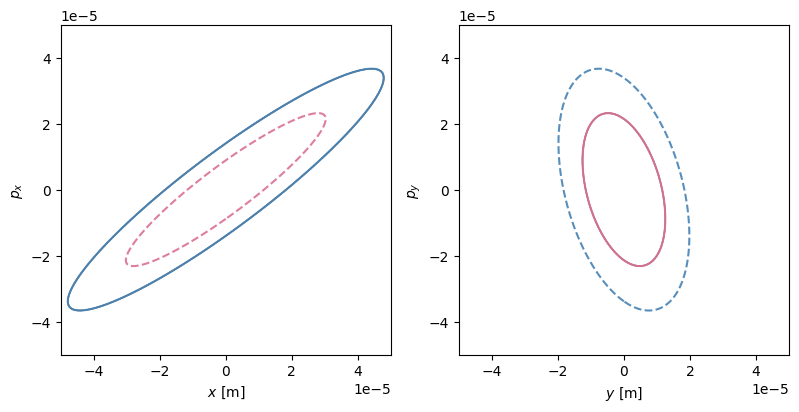

In [8]:

# Plotting
#--------------------------------------------------
x_color = 'steelblue'
y_color = 'palevioletred'

fig, axes = plt.subplots(1, 2, figsize=(8.1,4))

for torus,ls in zip([torus0, torus1],['-','--']):

    # TORUS SHADOW, plotting all possible angle values
    #=======================================================
    T_loop = np.linspace(0,2*np.pi,100)
    T_vals = np.linspace(0,2*np.pi,20)

    plt.sca(axes[0])
    for T0 in T_vals[:-1]:
        ptplt.loop(torus,proj='x',Tx=T_loop,Ty=T0,edgecolor='dimgrey',alpha=0.1,lw=1)

    plt.sca(axes[1])
    for T0 in T_vals[:-1]:
        ptplt.loop(torus,proj='y',Tx=T0,Ty=T_loop,edgecolor='dimgrey',alpha=0.1,lw=1)
    #=======================================================


    # Plotting a specific loop
    #=======================================================
    plt.sca(axes[0])
    # same as ptplt.xloop(torus,looping='x')
    ptplt.loop(torus,proj='x',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5,ls=ls)
    ptplt.loop(torus,proj='x',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5,ls=ls)

    plt.sca(axes[1])
    # same as ptplt.yloop(torus,looping='x')
    ptplt.loop(torus,proj='y',looping='x',edgecolor=x_color,alpha=0.9,lw=1.5,ls=ls)
    ptplt.loop(torus,proj='y',looping='y',edgecolor=y_color,alpha=0.9,lw=1.5,ls=ls)


for ax,plane in zip(axes,['x','y']):
    plt.sca(ax)
    plt.axis('equal')
    plt.gca().set_box_aspect(1) 
    plt.xlabel(rf'${plane}\ [\mathrm{{m}}]$');
    plt.ylabel(rf'$p_{plane}$');
    plt.xlim(-5e-5,5e-5)
    plt.ylim(-5e-5,5e-5)
plt.tight_layout()

(1e-10, 3.6e-10)

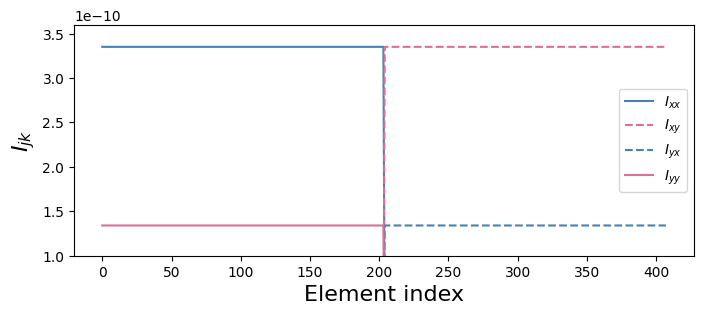

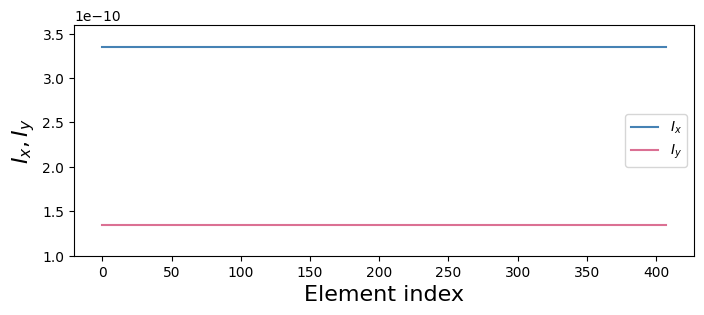

In [9]:
plt.figure(figsize=(8,3))
plt.plot(Ixx,color=x_color,ls='-',label='$I_{xx}$')
plt.plot(Ixy,color=y_color,ls='--',label='$I_{xy}$')
# plt.plot(Iyx,label='Iyx')
# plt.plot(Iyy,label='Iyy')
plt.xlabel('Element index')
plt.ylabel('Action invariants')
plt.legend()


plt.plot(Iyx,color=x_color,ls='--',label='$I_{yx}$')
plt.plot(Iyy,color=y_color,ls='-',label='$I_{yy}$')
# plt.plot(Iyx,label='Iyx')
# plt.plot(Iyy,label='Iyy')
plt.xlabel('Element index',fontsize=16)
plt.ylabel('$I_{jk}$',fontsize=16)
plt.legend()
plt.ylim(1e-10,3.6e-10)


plt.figure(figsize=(8,3))
plt.plot(Ixx + Ixy,color=x_color,ls='-',label='$I_{x}$')
plt.plot(Iyy + Iyx,color=y_color,ls='-',label='$I_{y}$')

plt.xlabel('Element index',fontsize=16)
plt.ylabel('$I_{x}, I_y$',fontsize=16)
plt.legend()
plt.ylim(1e-10,3.6e-10)

/Users/pbelanger/ABPLocal/BBStudies/Executables/miniforge3/envs/py-BB/lib/python3.10/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/pbelanger/ABPLocal/BBStudies/Executables/miniforge3/envs/py-BB/lib/python3.10/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


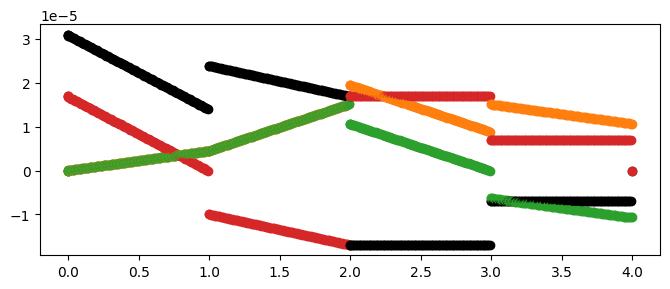

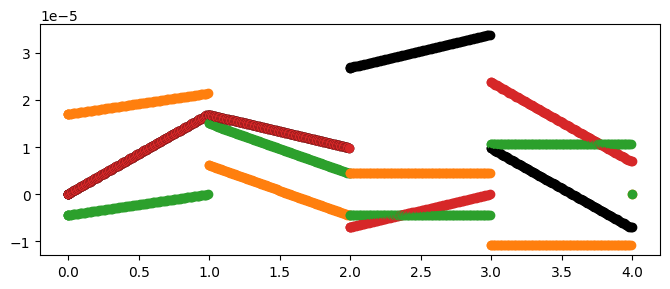

In [16]:
# Constructing matched torus from W-matrix (2D here)
x_sig  = 1
y_sig  = 1
nemitt_x = 5e-6
nemitt_y = 2e-6
torus0 = pt.Torus.linear_match(I=[(x_sig**2)/2,(y_sig**2)/2],
                               W_matrix=twiss.W_matrix[0],
                               nemitt_x=nemitt_x, 
                               nemitt_y=nemitt_y,
                               particle_on_co=twiss.particle_on_co)

# Tracking & plotting
plt.figure(figsize=(8,3))
torus = torus0.copy()
for ee,ee_name in zip(line.elements,line.element_names):
    if isinstance(ee,xt.Drift):
        torus = pt.transforms.drift(torus,ds=ee.length)
    elif isinstance(ee,xt.Multipole):
        torus = pt.transforms.multipole(torus,knl=ee.knl,ksl=ee.ksl)

    plt.plot(twiss.rows[ee_name].s, torus.x[(1,0)],'o',color='k')
    plt.plot(twiss.rows[ee_name].s, torus.x[(-1,0)],'o',color='C3')
    plt.plot(twiss.rows[ee_name].s, torus.x[(0,1)],'o',color='C1')
    plt.plot(twiss.rows[ee_name].s, torus.x[(0,-1)],'o',color='C2')


plt.figure(figsize=(8,3))
torus = torus0.copy()
for ee,ee_name in zip(line.elements,line.element_names):
    if isinstance(ee,xt.Drift):
        torus = pt.transforms.drift(torus,ds=ee.length)
    elif isinstance(ee,xt.Multipole):
        torus = pt.transforms.multipole(torus,knl=ee.knl,ksl=ee.ksl)

    plt.plot(twiss.rows[ee_name].s, torus.y[(1,0)],'o',color='k')
    plt.plot(twiss.rows[ee_name].s, torus.y[(-1,0)],'o',color='C3')
    plt.plot(twiss.rows[ee_name].s, torus.y[(0,1)],'o',color='C1')
    plt.plot(twiss.rows[ee_name].s, torus.y[(0,-1)],'o',color='C2')

In [18]:
Ixy

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

---
# Periodic emittance exchange
---

Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


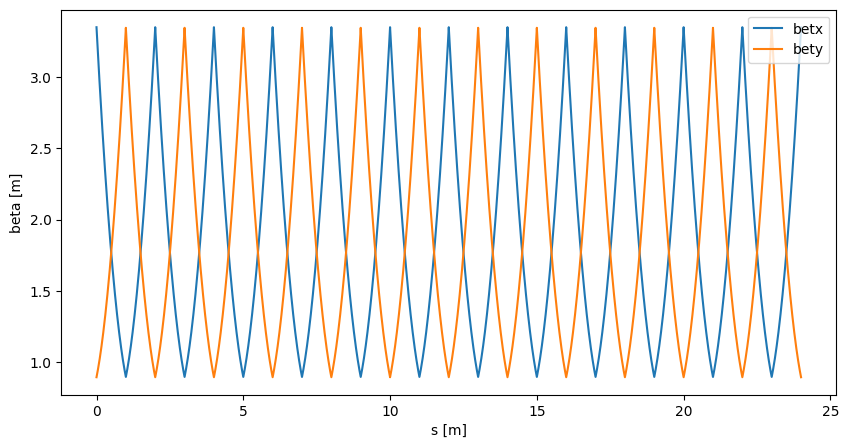

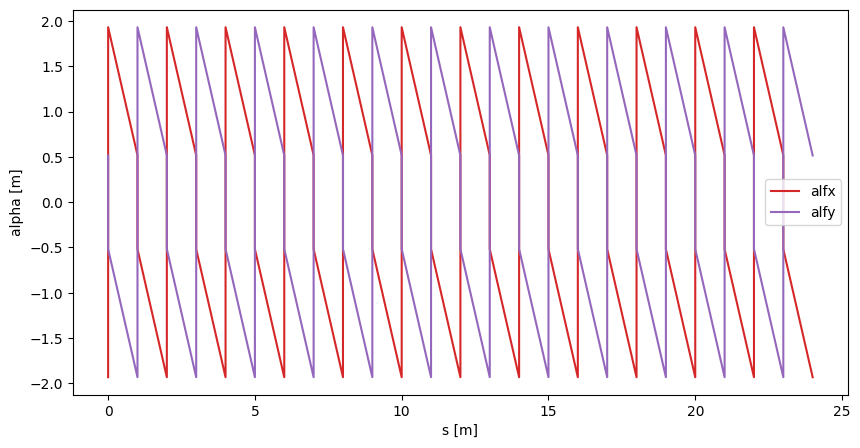

In [32]:
import numpy as np
import matplotlib.pyplot as plt

import nafflib
import pytori as pt
import pytori.plotting as ptplt

import xtrack as xt
import xobjects as xo


# CELL parameters
#-----------------------
L       = 1                 #-- drift length
k       = 2/np.sqrt(3)      #-- focusing strength
dk      = 0.001*k           #-- to split x-y tunes
supP    = 12                 #-- superperiods
divs    = 100               #-- drift divisions (for visualization)
#-----------------------


# ELEMENTS
#=========================================================================================
elements = {}
for n in range(supP):
    cell = {
            f'entry.{n}'        : xt.Marker(),
            f'QF.{n}'           : xt.Multipole(knl=[0, k],ksl=[0,0],length=0),
            **{f'O1.{n}.{i}'    : xt.Drift(length=L/divs) for i in range(divs)},
            f'QD.{n}'           : xt.Multipole(knl=[0,-k],ksl=[0,0],length=0),
            **{f'O2.{n}.{i}'    : xt.Drift(length=L/divs) for i in range(divs)},
        }
    elements.update(cell)
#=========================================================================================

# BEAM & XSUITE LINE
#=========================================================================================
nrj             = 7000e9
particle_ref    = xt.Particles(p0c=nrj, q0=1, mass0=xt.PROTON_MASS_EV)
context         = xo.ContextCpu(omp_num_threads='auto')
nemitt_x        = 2.5e-6
nemitt_y        = 2.5e-6
gemitt_x        = 1 if nemitt_x is None else ( nemitt_x / particle_ref.beta0[0] / particle_ref.gamma0[0])
gemitt_y        = 1 if nemitt_y is None else ( nemitt_y / particle_ref.beta0[0] / particle_ref.gamma0[0])
#-----------------------------------------------------------------------------------------
line = xt.Line(elements=elements)
line.particle_ref = particle_ref
line.build_tracker(_context=context)
# KNOBS
line.vars['k0'] = k
line.vars['dQ'] = dk
line.vars['dC'] = 0
for n in range(supP):
    # Normal Quadrupoles to set tunes
    line.element_refs[f'QF.{n}'].knl[1] =  line.vars['k0'] 
    line.element_refs[f'QD.{n}'].knl[1] = -(line.vars['k0']+line.vars['dQ'])
    # Skew Quadrupoles to set coupling
    line.element_refs[f'QF.{n}'].ksl[1] =  line.vars['dC'] 
    # line.element_refs[f'QD.{n}'].ksl[1] =  line.vars['dC'] 
#=========================================================================================
line.freeze_longitudinal(True)
twiss       = line.twiss4d()
#=========================================================================================


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.betx, label='betx')
plt.plot(twiss.s, twiss.bety, label='bety')
plt.xlabel('s [m]')
plt.ylabel('beta [m]')
plt.legend()


plt.figure(figsize=(10,5))
plt.plot(twiss.s, twiss.alfx, label='alfx',color='C3')
plt.plot(twiss.s, twiss.alfy, label='alfy',color='C4')
plt.xlabel('s [m]')
plt.ylabel('alpha [m]')
plt.legend()

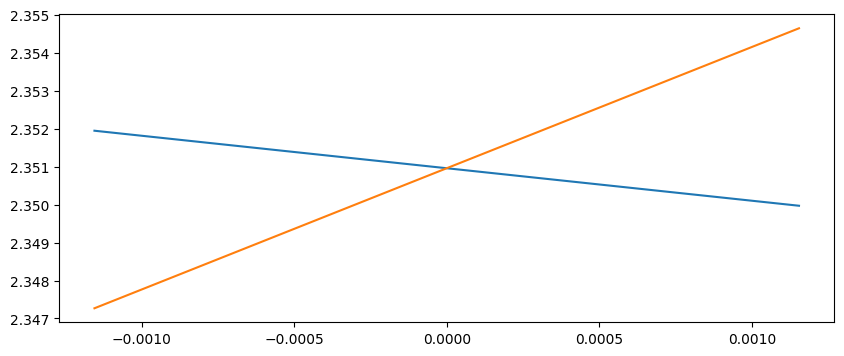

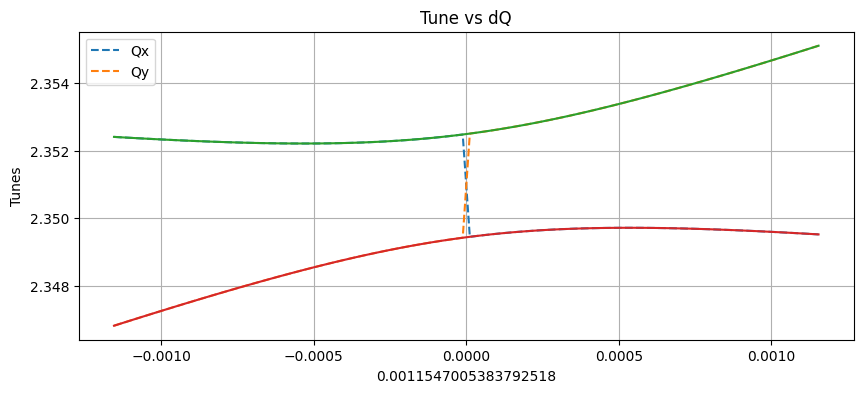

In [33]:

plt.figure(figsize=(10,4))

line.vars['dC'] = 0
qx0 = []
qy0 = []
dQ_vec = np.linspace(-dk,dk,100)
for dQ in dQ_vec:
    line.vars['dQ'] = dQ
    twiss       = line.twiss4d()
    qx0.append(twiss.qx)
    qy0.append(twiss.qy)
plt.plot(dQ_vec,qx0)
plt.plot(dQ_vec,qy0)



plt.figure(figsize=(10,4))
line.vars['dC'] = 0.8*dk
qx = []
qy = []
C  = []
dQ_vec = np.linspace(-dk,dk,100)
for dQ in dQ_vec:
    line.vars['dQ'] = dQ
    twiss       = line.twiss4d()
    qx.append(twiss.qx)
    qy.append(twiss.qy)
    C.append(twiss.c_minus)
plt.plot(dQ_vec,qx,'--')
plt.plot(dQ_vec,qy,'--')

DD = np.array(qx0)-np.array(qy0)
Q1 = (np.array(qx0)+np.array(qy0))/2 +np.sqrt((DD)**2 + np.array(C)**2)/2
Q2 = (np.array(qx0)+np.array(qy0))/2 -np.sqrt((DD)**2 + np.array(C)**2)/2

plt.plot(dQ_vec,Q1,'-')
plt.plot(dQ_vec,Q2,'-')
plt.xlabel(dQ)
plt.ylabel('Tunes')
plt.title('Tune vs dQ')
plt.legend(['Qx','Qy'])
plt.grid()


np.float64(0.0)